In [13]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


In [4]:
insurance_data= pd.read_csv("insurance.csv")

In [14]:
#  interaction features 
x=insurance_data.drop(columns=["charges"])
y=insurance_data['charges']

X= pd.get_dummies(x,columns=['region'],drop_first=True,dtype=int) 

# encoding the values sex m=1, f=0
X['sex']=X['sex'].map({'male':1,'female':0}) 
X['smoker']=X['smoker'].map({'yes':1,'no':0})
X['age_smoker']=X['age']* X['smoker']  # for those people whose age high (1) and smoker (1)then charges will be high 
X['bmi_smoker']=X['bmi']* X['smoker']
X.head()

# train test split   
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)


mse for alpha = 0.001 -> 20922599.871035967
mse for alpha = 0.01 -> 20922527.32662988
mse for alpha = 1 -> 20914832.63508914
mse for alpha = 2 -> 20908106.77995452
mse for alpha = 5 -> 20890881.000633497
mse for alpha = 10 -> 20872844.79479669
mse for alpha = 20 -> 20877828.532378834
mse for alpha = 30 -> 20937537.133939777
mse for alpha = 40 -> 21046489.29389078
mse for alpha = 50 -> 21196929.86960891
mse for alpha = 100 -> 22423172.68602325


<Axes: >

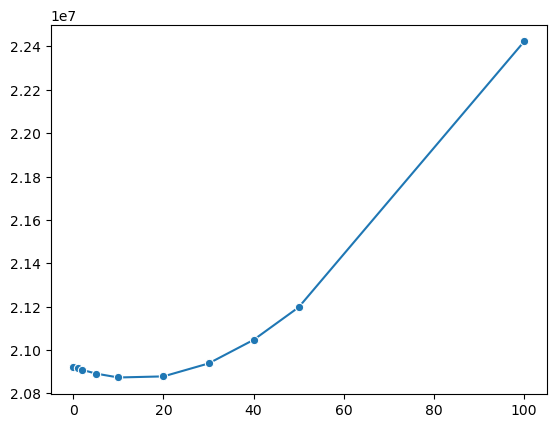

In [24]:
# apply lasso regression model
#  aplha -> strength of regurlarization 
import seaborn as sns

alphas=[0.001,0.01,1,2,5,10,20,30,40,50,100]

mses=[]
for alpha in alphas:
    lasso_model= Lasso(alpha=alpha)
    lasso_model.fit(X_train,y_train)
    y_predict= lasso_model.predict(X_test)
    mse= mean_squared_error(y_test,y_predict)
    print(f"mse for alpha = {alpha} -> {mse}")
    mses.append(mse)

sns.lineplot(x=alphas,y=mses,marker='o')




In [29]:
# Lasso Cv is ding cross validation 
from sklearn.linear_model import LassoCV
import seaborn as sns
alphas=[0.001,0.01,1,2,5,10,20,30,40,50,100]
lasso_cv_model=LassoCV(
    alphas=alphas,
    cv=5, # cross folds data is divided into chunks
    max_iter=500,
random_state=42   
)

lasso_cv_model.fit(X_train,y_train)
print(f"best alpha value: {lasso_cv_model.alpha_} ")
y_pred= lasso_cv_model.predict(X_test)
mse=mean_squared_error(y_test,y_pred)

r2=r2_score(y_test,y_pred)

print("MSE : ",mse)
print("R2- Score : ",r2 )

#  same as ridge cv 


best alpha value: 0.001 
MSE :  20922599.871035967
R2- Score :  0.8652317499151699
